In [2]:
# Librerías
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# ===== PLOT =====
def plot_cv_average_history_Cheb(histories_Cheb):
    max_epochs_Cheb = max([len(h.history['loss']) for h in histories_Cheb])
    epochs_Cheb = np.arange(1, max_epochs_Cheb + 1)

    def get_padded_metrics_Cheb(metric_name):
        matrix_Cheb = np.full((len(histories_Cheb), max_epochs_Cheb), np.nan)
        for i, h in enumerate(histories_Cheb):
            data_Cheb = h.history[metric_name]
            matrix_Cheb[i, :len(data_Cheb)] = data_Cheb
        return np.nanmean(matrix_Cheb, axis=0)

    avg_loss_Cheb = get_padded_metrics_Cheb('loss')
    avg_val_loss_Cheb = get_padded_metrics_Cheb('val_loss')
    avg_acc_Cheb = get_padded_metrics_Cheb('accuracy')
    avg_val_acc_Cheb = get_padded_metrics_Cheb('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_Cheb, avg_loss_Cheb)
    plt.plot(epochs_Cheb, avg_val_loss_Cheb)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_Cheb, avg_acc_Cheb)
    plt.plot(epochs_Cheb, avg_val_acc_Cheb)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [ ]:
class ChebyshevLayer(layers.Layer):
    def __init__(self, units, degree, **kwargs):
        super(ChebyshevLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree

    def build(self, input_shape):
        # Pesos para cada grado del polinomio
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="chebyshev_weights"
        )

    def call(self, inputs):
        # Valores iniciales de la recurrencia de Chebyshev
        # T0(x) = 1
        previous_previous_poly = tf.ones_like(inputs)

        # T1(x) = x
        previous_poly = inputs

        # Salida inicial con los dos primeros grados
        output_values = (
            tf.matmul(previous_previous_poly, self.w[0]) +
            tf.matmul(previous_poly, self.w[1])
        )

        # Aqui de forma recursiva generamos los otros grados 
        for degree_index in range(2, self.degree + 1):
            current_poly = 2.0 * inputs * previous_poly - previous_previous_poly

            output_values += tf.matmul(current_poly, self.w[degree_index])

            # Preparamos la siguiente iteración
            previous_previous_poly = previous_poly
            previous_poly = current_poly

        return output_values

In [ ]:
# ===== MODELO =====
def PolynomialDenseCreator_Cheb(degree_Cheb,input_dim_Cheb):
    inputPoli_Cheb = keras.Input(shape=(input_dim_Cheb,))
    
    x_Cheb = ChebyshevLayer(32, degree=degree_Cheb)(inputPoli_Cheb)
    x_Cheb = layers.Activation('swish')(x_Cheb)
    x_Cheb = layers.Dense(16, activation='swish')(x_Cheb)
    
    outputPoli_Cheb = layers.Dense(2, activation='softmax')(x_Cheb)
    
    model_Cheb = keras.Model(
        inputs=inputPoli_Cheb,
        outputs=outputPoli_Cheb,
        name=f"Polynomial_Model_Degree_{degree_Cheb}_Cheb"
    )
    
    model_Cheb.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model_Cheb


In [6]:

# ===== DATOS =====
magic_gamma_telescope_Cheb = fetch_ucirepo(id=159)

X_Cheb = magic_gamma_telescope_Cheb.data.features 
y_Cheb = magic_gamma_telescope_Cheb.data.targets 


# ===== HIPERPARÁMETROS =====
epochs_Cheb = 10
batch_size_Cheb = 32
input_dim_Cheb = X_Cheb.shape[1]
num_splits_Cheb = 10
degrees = [3, 5, 7]


In [7]:

def createEarlyStoppingCallback_Cheb(patience_Cheb=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience_Cheb,
        restore_best_weights=True
    )


In [8]:
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
skf_Cheb = StratifiedKFold(n_splits=num_splits_Cheb, shuffle=True, random_state=1)

history_Cheb = {deg: [] for deg in degrees}
score_Cheb = {deg: [] for deg in degrees}

X_Cheb = X_Cheb.to_numpy()
y_Cheb = y_Cheb.to_numpy()


for train_index, test_index in tqdm(skf_Cheb.split(X_Cheb, y_Cheb), total=num_splits_Cheb):

    X_train_Cheb, X_test_Cheb = X_Cheb[train_index], X_Cheb[test_index]
    y_train_Cheb, y_test_Cheb = y_Cheb[train_index], y_Cheb[test_index]

    scaler_Cheb = MinMaxScaler(feature_range=(-1, 1))
    X_train_scaled_Cheb = scaler_Cheb.fit_transform(X_train_Cheb)
    X_test_scaled_Cheb = scaler_Cheb.transform(X_test_Cheb)

    y_train_Cheb = (y_train_Cheb == 'g').astype(int)
    y_test_Cheb = (y_test_Cheb == 'g').astype(int)


    for deg in degrees:
        tf.keras.backend.clear_session()

        model = PolynomialDenseCreator_Cheb(deg, input_dim_Cheb=X_train_scaled_Cheb.shape[1])
        TranedModel = model.fit(X_train_scaled_Cheb, y_train_Cheb, validation_split=0.2, epochs=epochs_Cheb, batch_size=32, verbose=0)
        eval_result = model.evaluate(X_test_scaled_Cheb, y_test_Cheb, verbose=0)
        
        history_Cheb[deg].append(TranedModel)
        score_Cheb[deg].append(eval_result)




  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [03:44<00:00, 22.45s/it]



  RESULTADOS FINALES (Promedio CV - Chebyshev)
Grado 3: Pérdida Promedio = 0.3640, Precisión Promedio = 0.8505


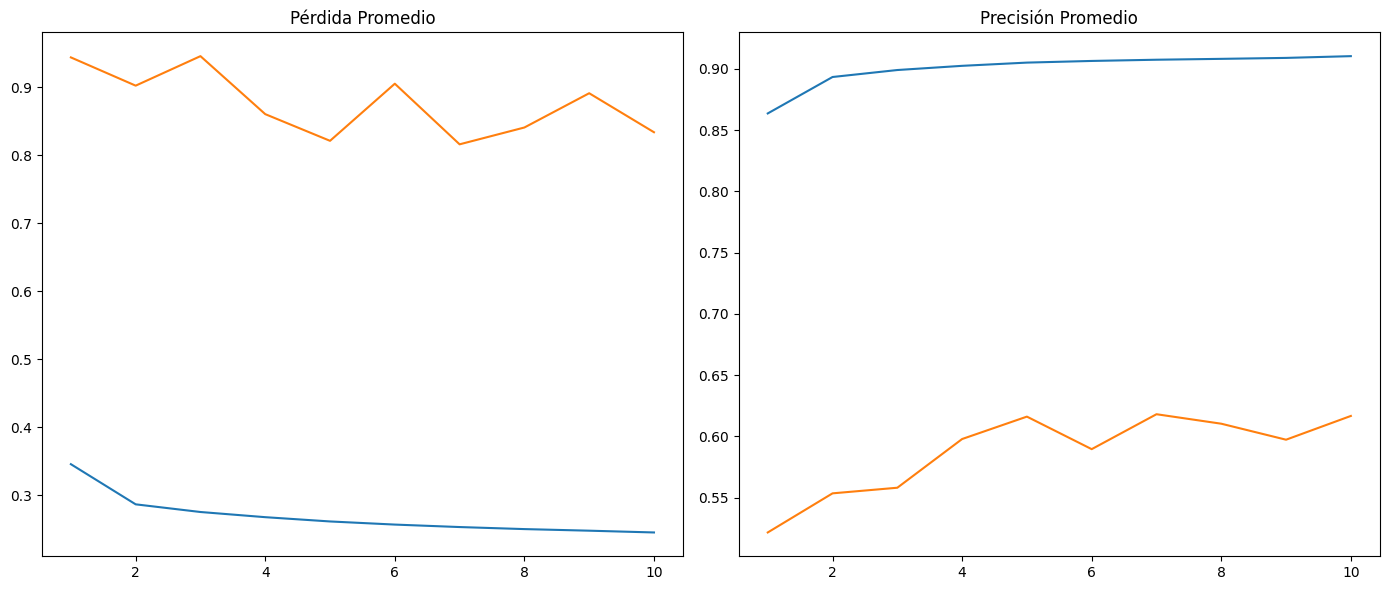

Grado 5: Pérdida Promedio = 0.3612, Precisión Promedio = 0.8537


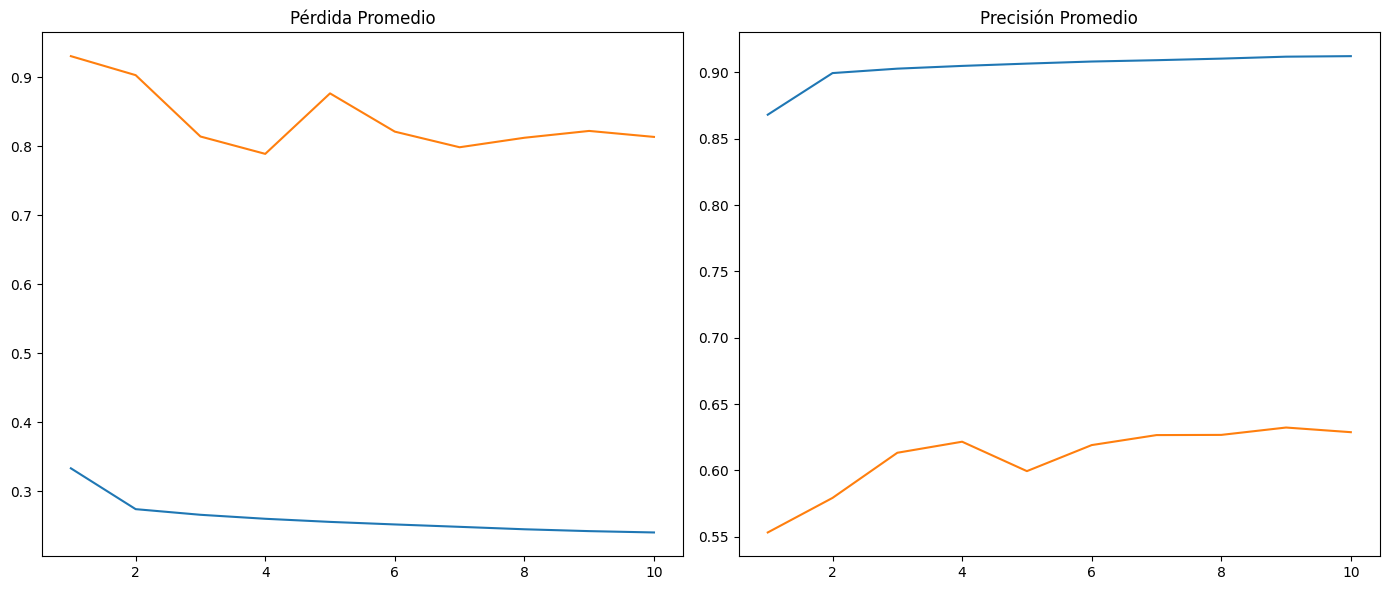

Grado 7: Pérdida Promedio = 0.3480, Precisión Promedio = 0.8605


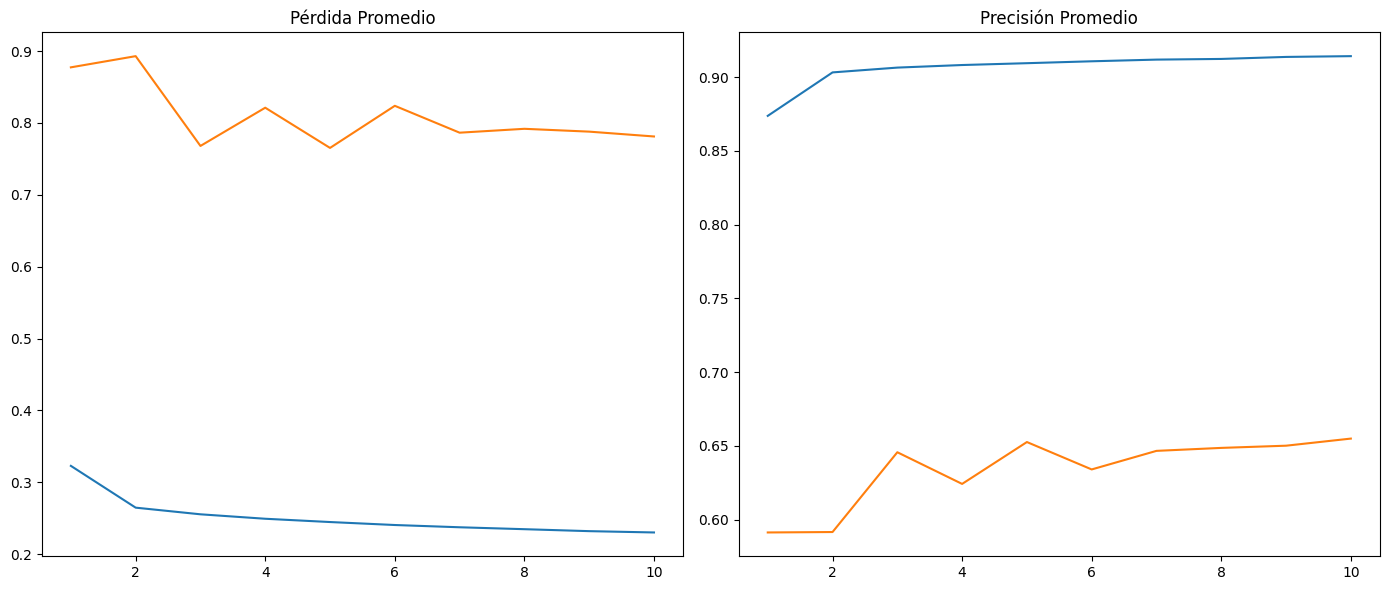

In [9]:

def calculator_Cheb(scores_Cheb):
    Totalloss_Cheb, Totalaccuracy_Cheb = 0, 0
    for loss, accuracy in scores_Cheb:
        Totalloss_Cheb += loss
        Totalaccuracy_Cheb += accuracy

    return Totalloss_Cheb/num_splits_Cheb, Totalaccuracy_Cheb/num_splits_Cheb


print("\n" + "="*40)
print("  RESULTADOS FINALES (Promedio CV - Chebyshev)")
print("="*40)

scoreMean_Cheb = {}
for deg in degrees:
    scoreMean_Cheb[deg] = calculator_Cheb(score_Cheb[deg])
    print(f"Grado {deg}: Pérdida Promedio = {scoreMean_Cheb[deg][0]:.4f}, Precisión Promedio = {scoreMean_Cheb[deg][1]:.4f}")
    plot_cv_average_history_Cheb(history_Cheb[deg])


In [10]:
import pandas as pd
import os

def save_results_to_csv_Chebyshev(scoreMean_dict, degrees_list, filename="temp_res_chebyshev.csv"):
    """
    Guarda los resultados del modelo Chebyshev en ../resultados/
    """
    # 1. Definir la ruta de la carpeta (un nivel arriba '..', carpeta 'resultados')
    carpeta_destino = os.path.join("..", "resultados")
    
    # 2. Crear la ruta completa del archivo
    ruta_completa = os.path.join(carpeta_destino, filename)
    
    data = []
    
    # 3. Extraer los datos del diccionario scoreMean_Cheb que creaste en tu bucle
    for deg in degrees_list:
        avg_loss = scoreMean_dict[deg][0]
        avg_accuracy = scoreMean_dict[deg][1]
        
        data.append({
            "Polinomio": "Chebyshev",
            "Grado": deg,
            "Mejor_N": "N/A",  # Chebyshev no usa el parámetro N de Shmaliy
            "Loss_Promedio": round(avg_loss, 6),
            "Accuracy_Promedio": round(avg_accuracy, 6)
        })
        
    # 4. Crear DataFrame y guardar
    df_resultados = pd.DataFrame(data)
    df_resultados.to_csv(ruta_completa, index=False, sep=';')
    
    print(f"\n[INFO] Resultados de Chebyshev guardados en:\n ---> '{os.path.abspath(ruta_completa)}'")


In [11]:

# ===== LLAMADA A LA FUNCIÓN =====
# Pon esto al final de tu notebook, después de los prints de resultados
save_results_to_csv_Chebyshev(scoreMean_Cheb, degrees, filename="temp_res_chebyshev.csv")

OSError: Cannot save file into a non-existent directory: '..\resultados'